In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Data Analytics environment is ready!")

Data Analytics environment is ready!


In [3]:
# Load the dataset

file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [7]:
[
    'InvoiceNo',
    'StockCode',
    'Description',
    'Quantity',
    'InvoiceDate',
    'UnitPrice',
    'CustomerID',
    'Country'
]

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()


np.int64(5268)

In [10]:
df_raw = df.copy()

print("Original dataset:", df_raw.shape)

Original dataset: (541909, 8)


In [11]:
df = df.drop_duplicates().copy()

print("After removing duplicates:", df.shape)

After removing duplicates: (536641, 8)


In [12]:
df[df["CustomerID"].isnull()].head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [13]:
df[df["Description"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [14]:
df = df.dropna(subset=["Description"]).copy()

print("After handling missing descriptions:", df.shape)

After handling missing descriptions: (535187, 8)


In [15]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133583
Country             0
dtype: int64

In [16]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [17]:
(df["Quantity"] < 0).sum()

np.int64(9725)

In [18]:
(df["UnitPrice"] <= 0).sum()

np.int64(1058)

In [19]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [20]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [21]:
df_raw = df.copy()

print("Original dataset:", df_raw.shape)

Original dataset: (535187, 9)


In [22]:
df = df.drop_duplicates().copy()

print("After removing duplicates:", df.shape)

After removing duplicates: (535187, 9)


In [23]:
df[df["CustomerID"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,3.32
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom,14.94


In [24]:
df = df.dropna(subset=["Description"]).copy()

print("After handling missing descriptions:", df.shape)

After handling missing descriptions: (535187, 9)


In [25]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133583
Country             0
Revenue             0
dtype: int64

In [26]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [27]:
(df["Quantity"] < 0).sum()

np.int64(9725)

In [28]:
(df["UnitPrice"] <= 0).sum()

np.int64(1058)

In [29]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [30]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [31]:
# Create final clean dataset for sales analysis

df_clean = df.copy()

# Remove cancelled transactions
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only positive quantities
df_clean = df_clean[df_clean["Quantity"] > 0]

# Keep only positive unit prices
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Reset index
df_clean = df_clean.reset_index(drop=True)

print("Final clean dataset shape:", df_clean.shape)

Final clean dataset shape: (524878, 9)


In [32]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

In [33]:
(df_clean["Quantity"] <= 0).sum()

np.int64(0)

In [34]:
(df_clean["UnitPrice"] <= 0).sum()

np.int64(0)

In [36]:
df_clean["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

In [37]:
df_clean["Revenue"].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [38]:
# Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Create date-related columns
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["MonthName"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Day"] = df_clean["InvoiceDate"].dt.day
df_clean["Weekday"] = df_clean["InvoiceDate"].dt.day_name()

In [39]:
df_clean[
    [
        "InvoiceDate",
        "Year",
        "Month",
        "MonthName",
        "Day",
        "Weekday"
    ]
].head()

,InvoiceDate,Year,Month,MonthName,Day,Weekday
0,2010-12-01 08:26:00,2010,12,December,1,Wednesday
1,2010-12-01 08:26:00,2010,12,December,1,Wednesday
2,2010-12-01 08:26:00,2010,12,December,1,Wednesday
3,2010-12-01 08:26:00,2010,12,December,1,Wednesday
4,2010-12-01 08:26:00,2010,12,December,1,Wednesday


In [40]:
total_revenue = df_clean["Revenue"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["InvoiceNo"].nunique()
total_products = df_clean["StockCode"].nunique()
total_countries = df_clean["Country"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Countries:", total_countries)

Total Revenue: 10642110.8
Total Quantity Sold: 5572420
Total Orders: 19960
Total Products: 3922
Total Countries: 38


In [41]:
total_customers = df_clean["CustomerID"].nunique()

print("Unique Customers:", total_customers)

Unique Customers: 4338


In [42]:
# Save the cleaned dataset

output_path = "../data/online_retail_clean.csv"

df_clean.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_path)

Cleaned dataset saved successfully!
File: ../data/online_retail_clean.csv


In [43]:
# Verify the saved dataset

df_test = pd.read_csv("../data/online_retail_clean.csv")

print("Saved dataset shape:", df_test.shape)
print("Saved dataset columns:", len(df_test.columns))

Saved dataset shape: (524878, 14)
Saved dataset columns: 14


C:\Users\fazil\AppData\Local\Temp\ipykernel_7964\190974393.py:3: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv("../data/online_retail_clean.csv")


In [44]:
df_clean.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'Revenue',
 'Year',
 'Month',
 'MonthName',
 'Day',
 'Weekday']

In [45]:
df_clean.shape

(524878, 14)

In [46]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Day,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday


In [47]:
df_clean.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'Revenue',
 'Year',
 'Month',
 'MonthName',
 'Day',
 'Weekday']

In [48]:
cleaning_summary = pd.DataFrame({
    "Stage": [
        "Original dataset",
        "After duplicate removal",
        "After missing Description removal",
        "After removing cancelled transactions",
        "After removing non-positive quantities",
        "After removing non-positive prices"
    ],
    "Rows": [
        541909,
        536641,
        535187,
        len(df[~df["InvoiceNo"].astype(str).str.startswith("C")]),
        len(df[(~df["InvoiceNo"].astype(str).str.startswith("C")) & (df["Quantity"] > 0)]),
        len(df_clean)
    ]
})

cleaning_summary

,Stage,Rows
0,Original dataset,541909
1,After duplicate removal,536641
2,After missing Description removal,535187
3,After removing cancelled transactions,525936
4,After removing non-positive quantities,525462
5,After removing non-positive prices,524878


In [50]:
df_clean.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'Revenue',
 'Year',
 'Month',
 'MonthName',
 'Day',
 'Weekday']

In [51]:
df_clean.shape

(524878, 14)

In [54]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Day,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday


In [55]:
df_clean.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'Revenue',
 'Year',
 'Month',
 'MonthName',
 'Day',
 'Weekday']

In [56]:
# Descriptive statistics for numerical variables

df_clean[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [57]:
# Basic dataset information

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Date range:")
print(df_clean["InvoiceDate"].min(), "to", df_clean["InvoiceDate"].max())

Rows: 524878
Columns: 14
Date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [58]:
# Number of unique values

print("Unique invoices:", df_clean["InvoiceNo"].nunique())
print("Unique products:", df_clean["StockCode"].nunique())
print("Unique customers:", df_clean["CustomerID"].nunique())
print("Unique countries:", df_clean["Country"].nunique())

Unique invoices: 19960
Unique products: 3922
Unique customers: 4338
Unique countries: 38


In [59]:
monthly_sales = (
    df_clean
    .groupby(["Year", "Month"], as_index=False)["Revenue"]
    .sum()
)

monthly_sales

,Year,Month,Revenue
0,2010,12,821452.730
1,2011,1,689811.610
2,2011,2,522545.560
3,2011,3,716215.260
4,2011,4,536968.491
5,2011,5,769296.610
6,2011,6,760547.010
7,2011,7,718076.121
8,2011,8,757841.380
9,2011,9,1056435.192


In [60]:
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("Date")

monthly_sales.head()

,Year,Month,Revenue,Date
0,2010,12,821452.730,2010-12-01
1,2011,1,689811.610,2011-01-01
2,2011,2,522545.560,2011-02-01
3,2011,3,716215.260,2011-03-01
4,2011,4,536968.491,2011-04-01


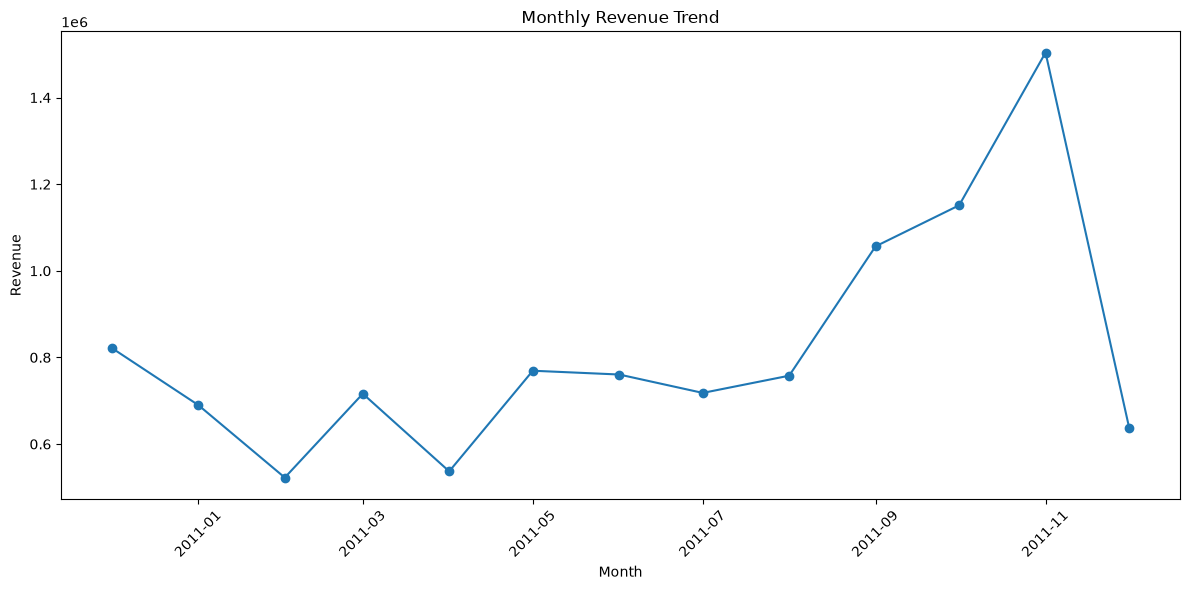

In [61]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [62]:
country_sales = (
    df_clean
    .groupby("Country", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

country_sales.head(10)

,Country,Revenue
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


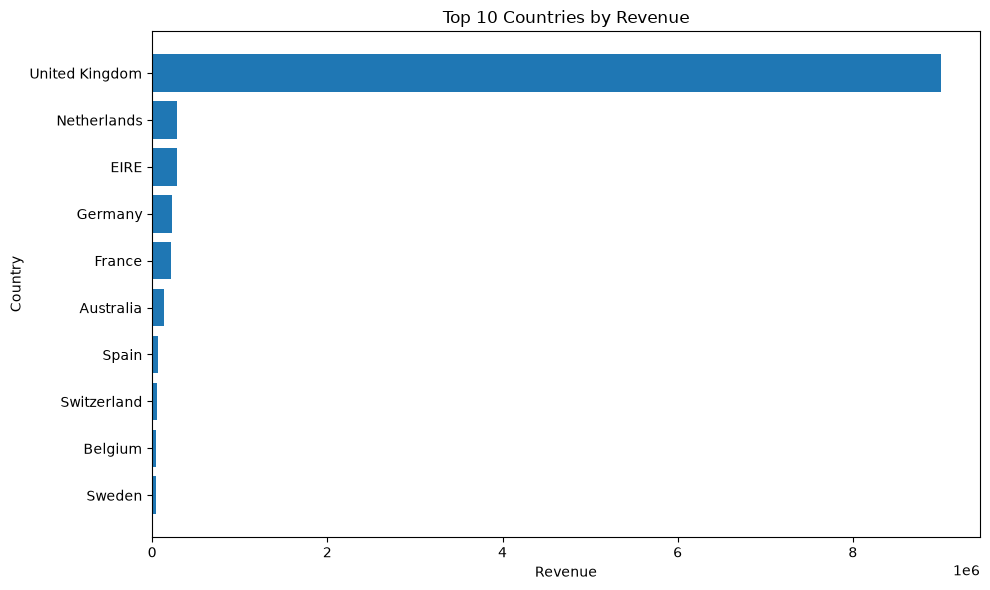

In [63]:
top_countries = country_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"][::-1],
    top_countries["Revenue"][::-1]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [64]:
product_sales = (
    df_clean
    .groupby("Description", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

product_sales.head(10)

,Description,Revenue
1067,DOTCOM POSTAGE,206248.77
2853,REGENCY CAKESTAND 3 TIER,174156.54
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3844,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
2413,PARTY BUNTING,99445.23
1816,JUMBO BAG RED RETROSPOT,94159.81
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
2692,POSTAGE,78101.88
2192,Manual,77752.82
2741,RABBIT NIGHT LIGHT,66870.03


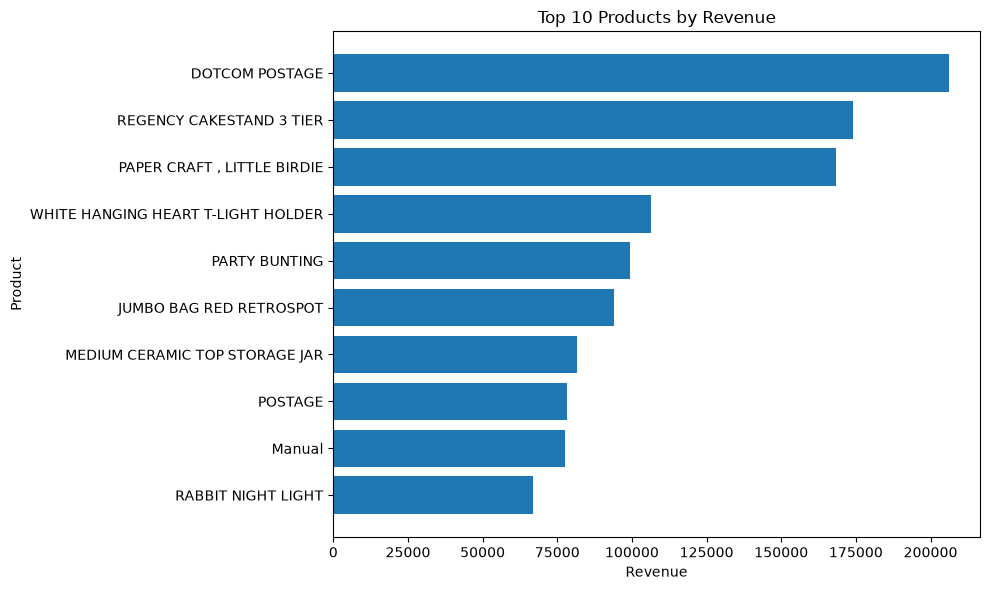

In [65]:
top_products = product_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"][::-1],
    top_products["Revenue"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [66]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [67]:
country_sales.head(10)

,Country,Revenue
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


In [68]:
country_sales.head(10)

,Country,Revenue
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


In [69]:
country_sales["Revenue"].sum()

np.float64(10642110.804)

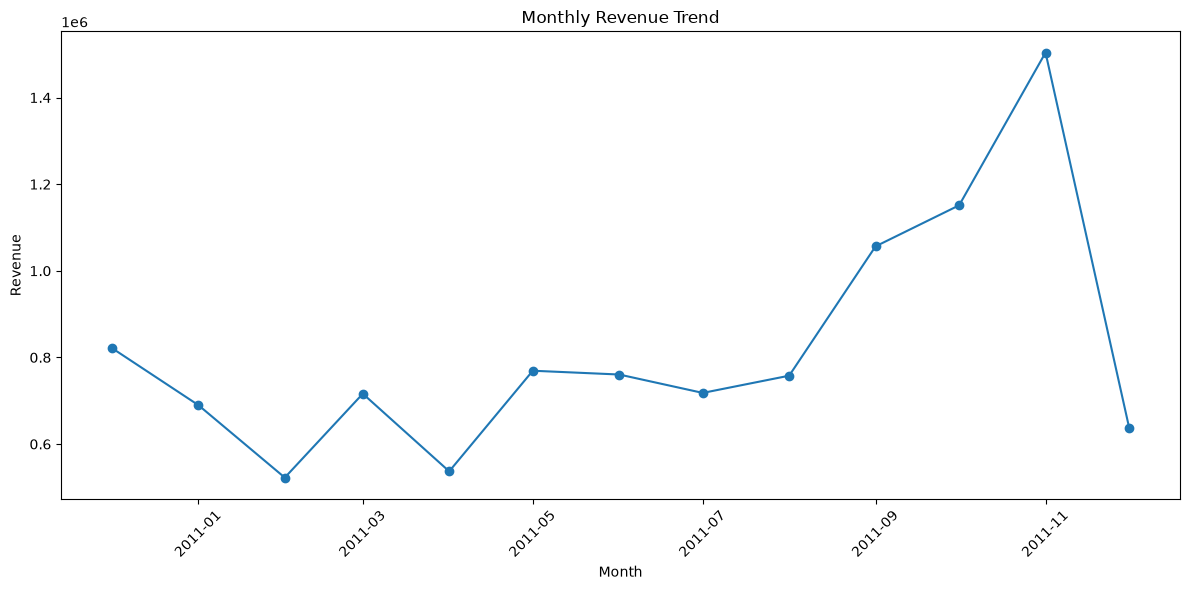

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [71]:
product_sales.head(10)

,Description,Revenue
1067,DOTCOM POSTAGE,206248.77
2853,REGENCY CAKESTAND 3 TIER,174156.54
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3844,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
2413,PARTY BUNTING,99445.23
1816,JUMBO BAG RED RETROSPOT,94159.81
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
2692,POSTAGE,78101.88
2192,Manual,77752.82
2741,RABBIT NIGHT LIGHT,66870.03


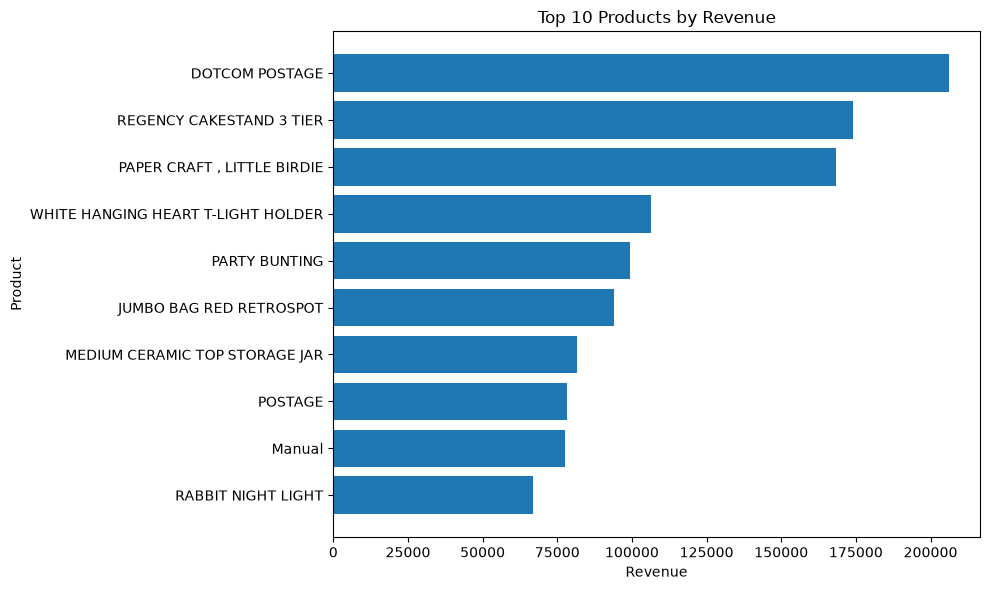

In [72]:
top_products = product_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"][::-1],
    top_products["Revenue"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

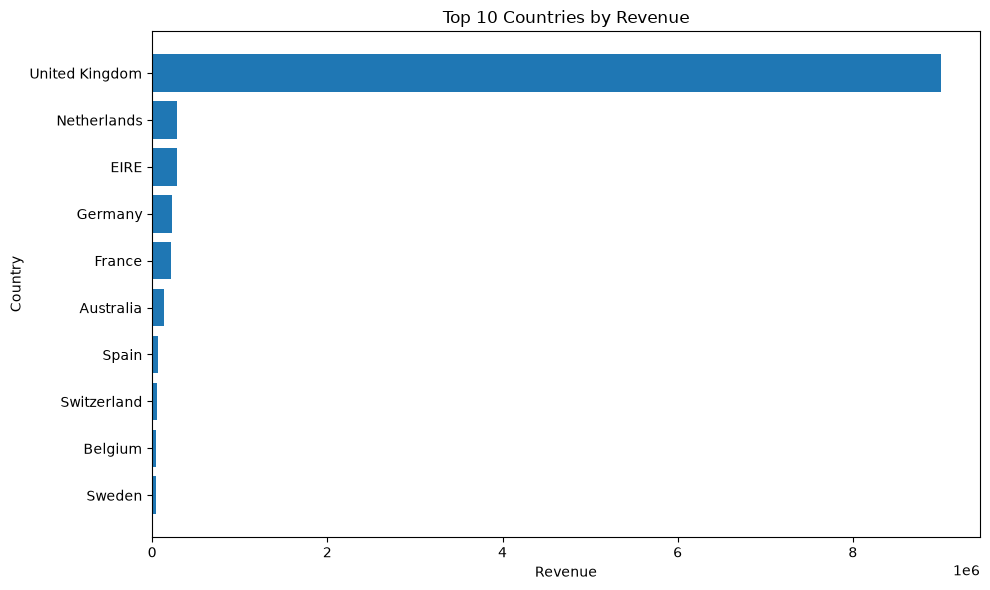

In [73]:
top_countries = country_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"][::-1],
    top_countries["Revenue"][::-1]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [74]:
df_clean.nlargest(10, "Revenue")[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "CustomerID",
        "Country"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
523404,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
59649,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
215474,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom
14456,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
290506,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
167609,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
337516,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom
50902,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
155191,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
408207,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands


In [75]:
Q1 = df_clean["Revenue"].quantile(0.25)
Q3 = df_clean["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3.9
Q3: 17.700000000000003
IQR: 13.800000000000002
Lower Bound: -16.800000000000004
Upper Bound: 38.400000000000006


In [76]:
outliers = df_clean[
    (df_clean["Revenue"] < lower_bound) |
    (df_clean["Revenue"] > upper_bound)
]

print("Number of Revenue outliers:", len(outliers))
print("Percentage of dataset:", round(len(outliers) / len(df_clean) * 100, 2), "%")

Number of Revenue outliers: 42624
Percentage of dataset: 8.12 %


In [77]:
customer_sales = (
    df_clean.dropna(subset=["CustomerID"])
    .groupby("CustomerID", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

customer_sales.head(10)

,CustomerID,Revenue
1689,14646.0,280206.02
4201,18102.0,259657.30
3728,17450.0,194390.79
3008,16446.0,168472.50
1879,14911.0,143711.17
55,12415.0,124914.53
1333,14156.0,117210.08
3771,17511.0,91062.38
2702,16029.0,80850.84
0,12346.0,77183.60


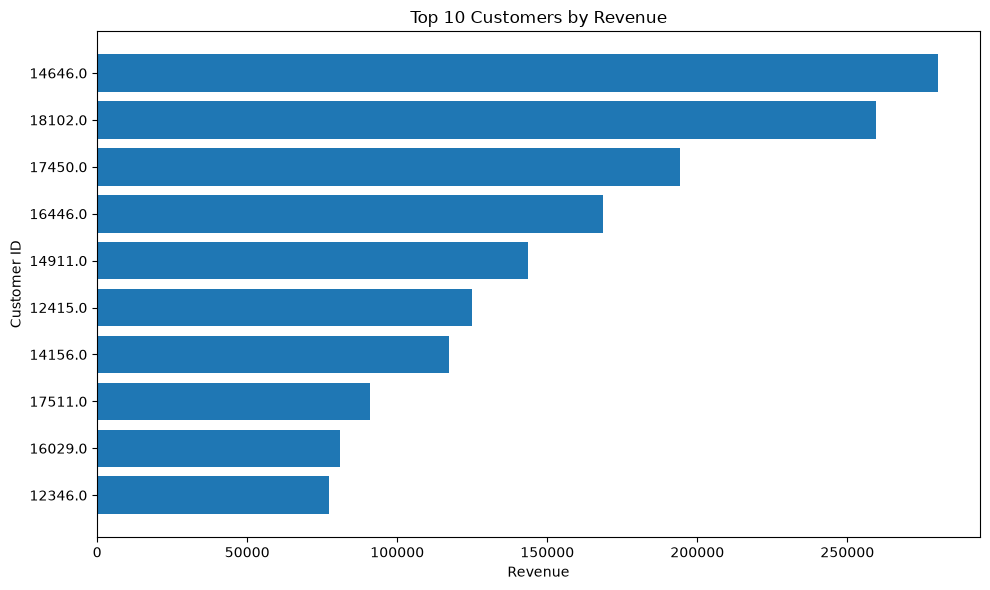

In [78]:
top_customers = customer_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["CustomerID"].astype(str)[::-1],
    top_customers["Revenue"][::-1]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

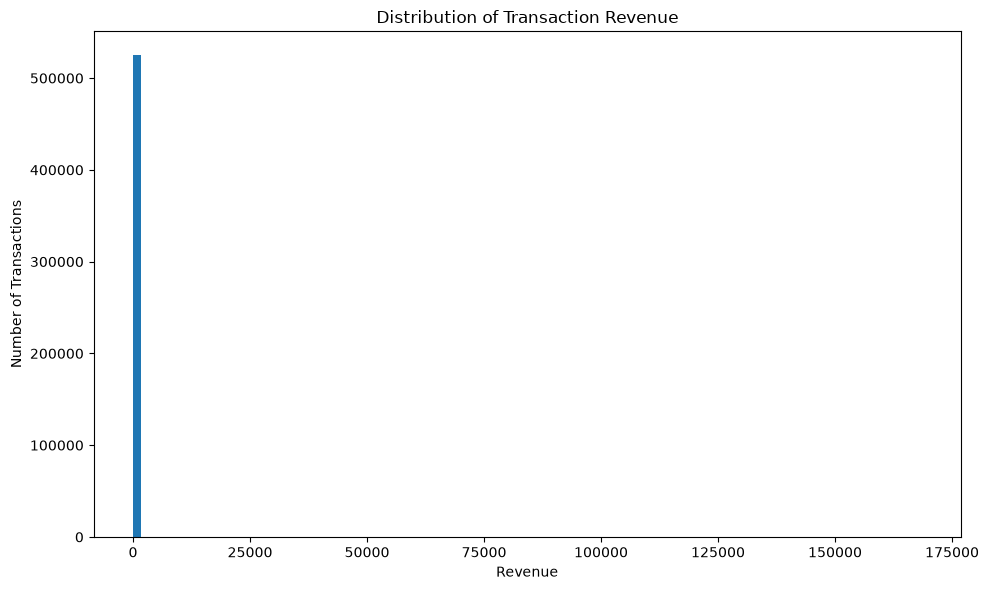

In [79]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["Revenue"],
    bins=100
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [80]:
monthly_sales

,Year,Month,Revenue,Date
0,2010,12,821452.730,2010-12-01
1,2011,1,689811.610,2011-01-01
2,2011,2,522545.560,2011-02-01
3,2011,3,716215.260,2011-03-01
4,2011,4,536968.491,2011-04-01
5,2011,5,769296.610,2011-05-01
6,2011,6,760547.010,2011-06-01
7,2011,7,718076.121,2011-07-01
8,2011,8,757841.380,2011-08-01
9,2011,9,1056435.192,2011-09-01


In [81]:
product_sales.head(10)

,Description,Revenue
1067,DOTCOM POSTAGE,206248.77
2853,REGENCY CAKESTAND 3 TIER,174156.54
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3844,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
2413,PARTY BUNTING,99445.23
1816,JUMBO BAG RED RETROSPOT,94159.81
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
2692,POSTAGE,78101.88
2192,Manual,77752.82
2741,RABBIT NIGHT LIGHT,66870.03


In [82]:
df_clean.nlargest(10, "Revenue")[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "Revenue",
     "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
523404,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
59649,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
215474,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom
14456,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
290506,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
167609,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
337516,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom
50902,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
155191,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
408207,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands


In [83]:
customer_sales.head(10)

,CustomerID,Revenue
1689,14646.0,280206.02
4201,18102.0,259657.30
3728,17450.0,194390.79
3008,16446.0,168472.50
1879,14911.0,143711.17
55,12415.0,124914.53
1333,14156.0,117210.08
3771,17511.0,91062.38
2702,16029.0,80850.84
0,12346.0,77183.60


In [84]:
# Correlation analysis

correlation = df_clean[["Quantity", "UnitPrice", "Revenue"]].corr()

correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Revenue,0.907402,0.137381,1.000000


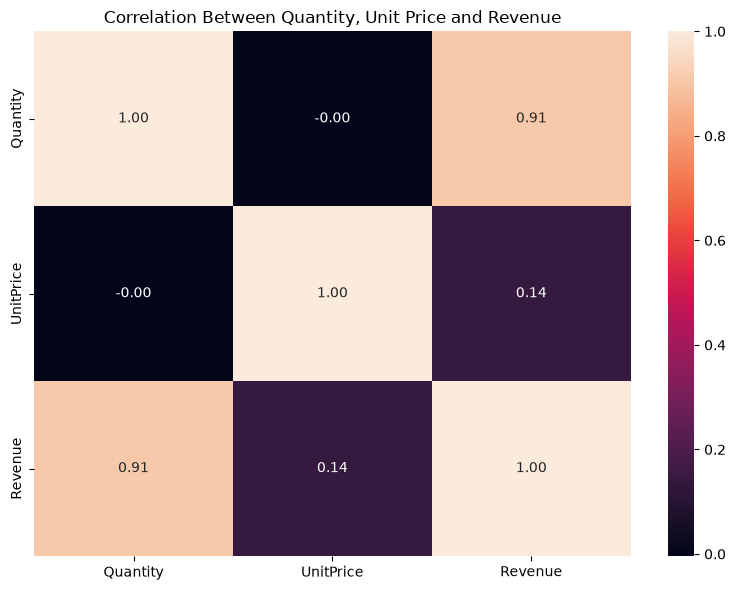

In [85]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Quantity, Unit Price and Revenue")
plt.tight_layout()

plt.show()

In [86]:
correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Revenue,0.907402,0.137381,1.000000


In [87]:
yearly_sales = (
    df_clean
    .groupby("Year", as_index=False)["Revenue"]
    .sum()
)

yearly_sales

,Year,Revenue
0,2010,821452.730
1,2011,9820658.074


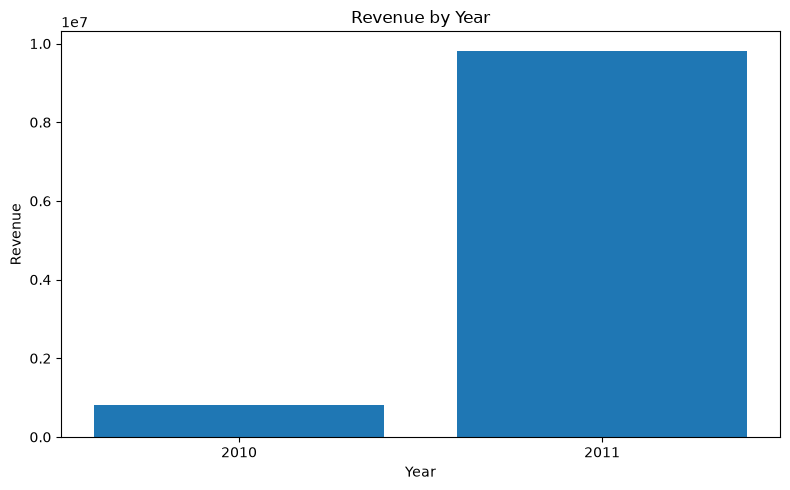

In [88]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Revenue"]
)

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [89]:
weekday_sales = (
    df_clean
    .groupby("Weekday", as_index=False)["Revenue"]
    .sum()
)

weekday_sales

,Weekday,Revenue
0,Friday,1837470.491
1,Monday,1775782.071
2,Sunday,806790.781
3,Thursday,2199292.570
4,Tuesday,2175700.511
5,Wednesday,1847074.380


In [90]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales["Weekday"] = pd.Categorical(
    weekday_sales["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_sales = weekday_sales.sort_values("Weekday")

weekday_sales

,Weekday,Revenue
1,Monday,1775782.071
4,Tuesday,2175700.511
5,Wednesday,1847074.380
3,Thursday,2199292.570
0,Friday,1837470.491
2,Sunday,806790.781


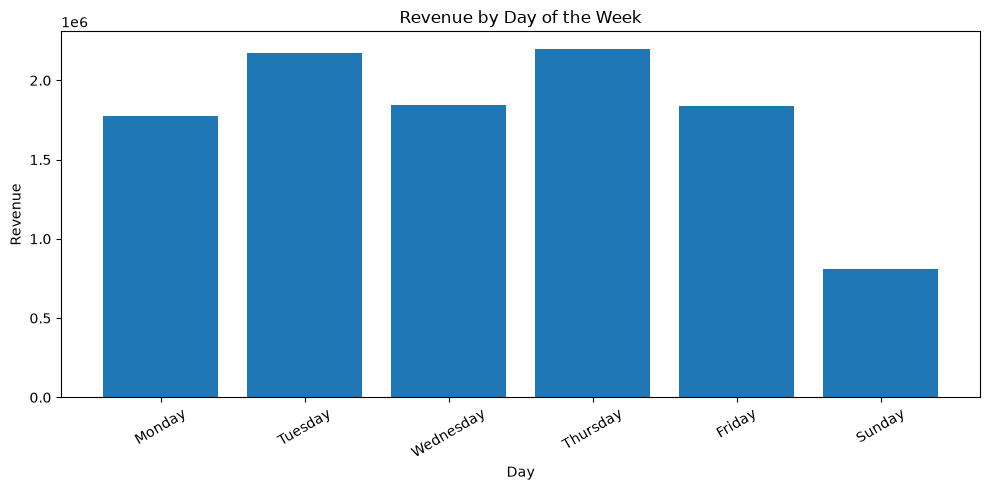

In [91]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_sales["Weekday"],
    weekday_sales["Revenue"]
)

plt.title("Revenue by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [92]:
monthly_quantity = (
    df_clean
    .groupby(["Year", "Month"], as_index=False)["Quantity"]
    .sum()
)

monthly_quantity.head()

,Year,Month,Quantity
0,2010,12,358019
1,2011,1,387099
2,2011,2,282934
3,2011,3,376599
4,2011,4,307953


In [93]:
monthly_quantity["Date"] = pd.to_datetime(
    monthly_quantity["Year"].astype(str) + "-" +
    monthly_quantity["Month"].astype(str) + "-01"
)

monthly_quantity = monthly_quantity.sort_values("Date")

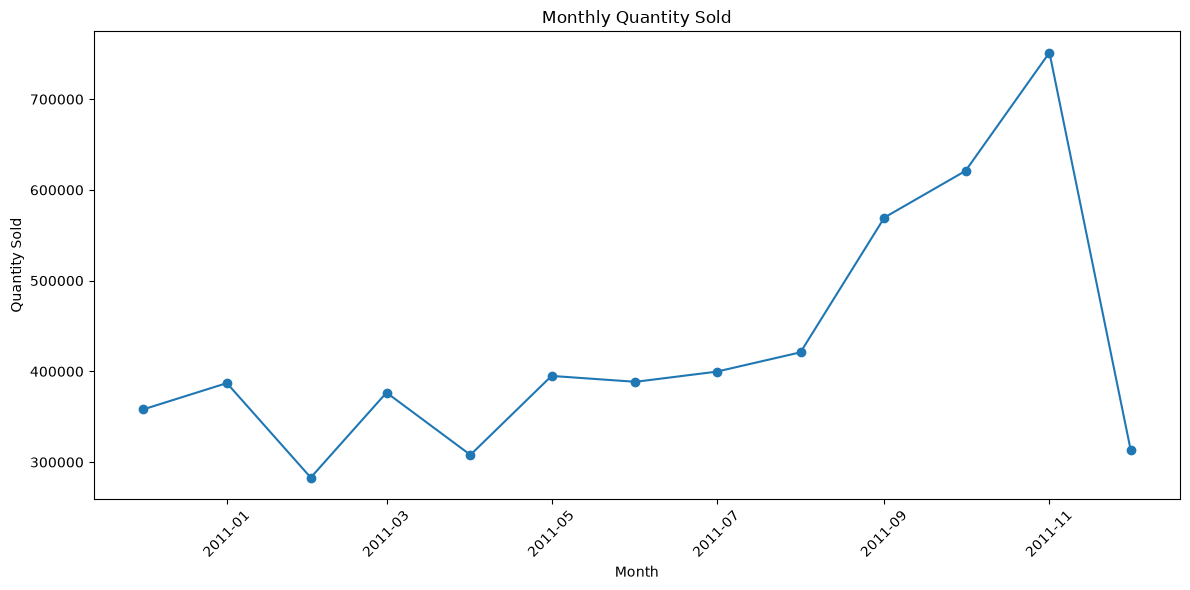

In [94]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_quantity["Date"],
    monthly_quantity["Quantity"],
    marker="o"
)

plt.title("Monthly Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [95]:
correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Revenue,0.907402,0.137381,1.000000


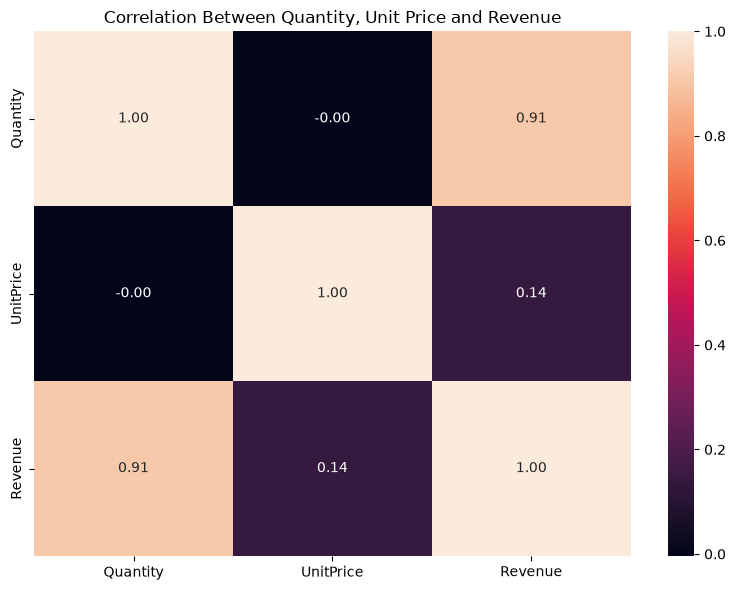

In [96]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Quantity, Unit Price and Revenue")
plt.tight_layout()

plt.show()

In [97]:
monthly_quantity = (
    df_clean
    .groupby(["Year", "Month"], as_index=False)["Quantity"]
    .sum()
)

monthly_quantity["Date"] = pd.to_datetime(
    monthly_quantity["Year"].astype(str) + "-" +
    monthly_quantity["Month"].astype(str) + "-01"
)

monthly_quantity = monthly_quantity.sort_values("Date")

monthly_quantity.head()

,Year,Month,Quantity,Date
0,2010,12,358019,2010-12-01
1,2011,1,387099,2011-01-01
2,2011,2,282934,2011-02-01
3,2011,3,376599,2011-03-01
4,2011,4,307953,2011-04-01


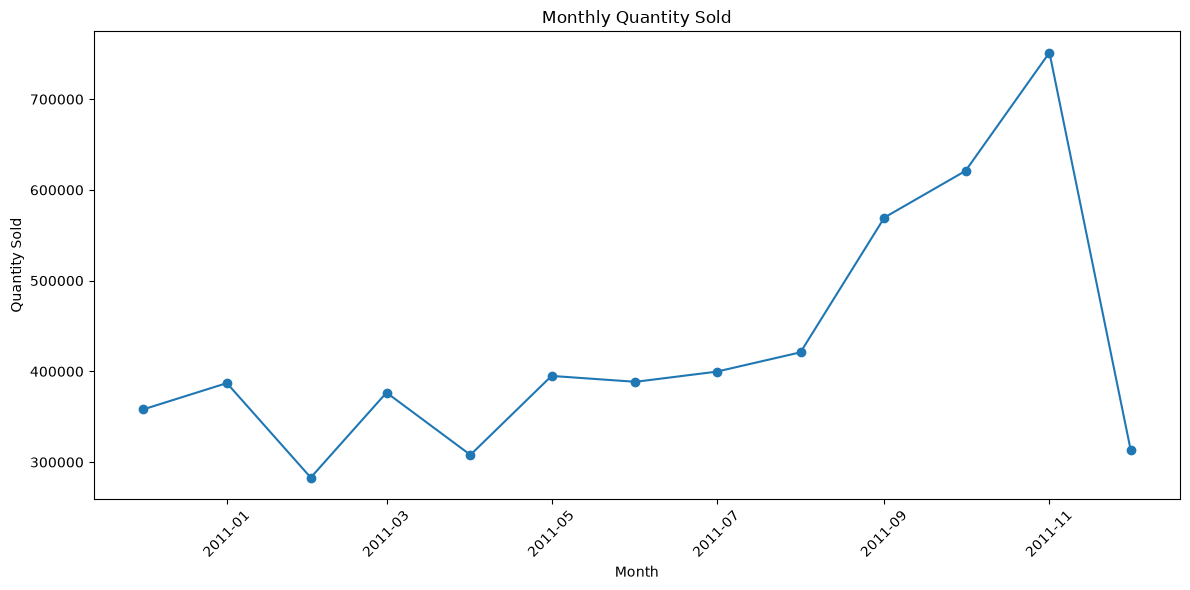

In [98]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_quantity["Date"],
    monthly_quantity["Quantity"],
    marker="o"
)

plt.title("Monthly Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

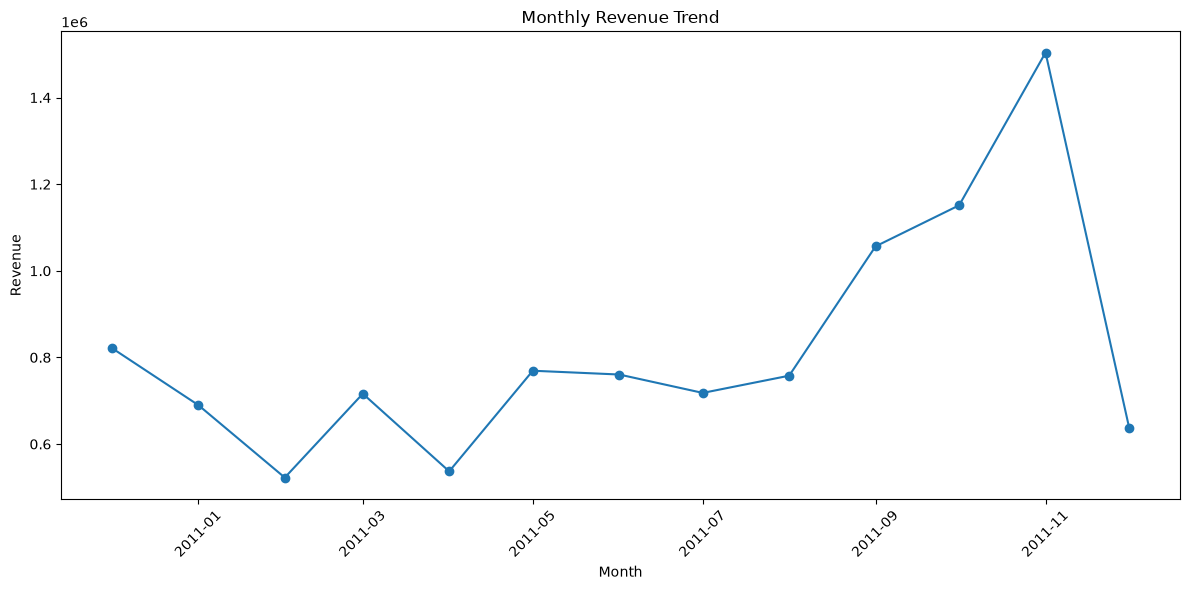

In [99]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualizations/monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

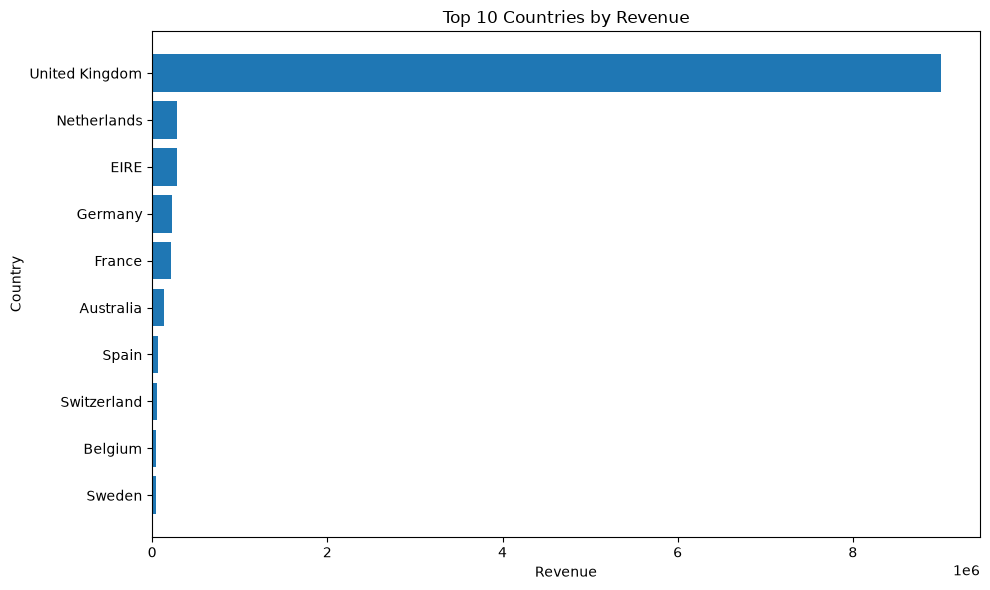

In [100]:
plt.figure(figsize=(10, 6))

top_countries = country_sales.head(10)

plt.barh(
    top_countries["Country"][::-1],
    top_countries["Revenue"][::-1]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("../visualizations/top_countries_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

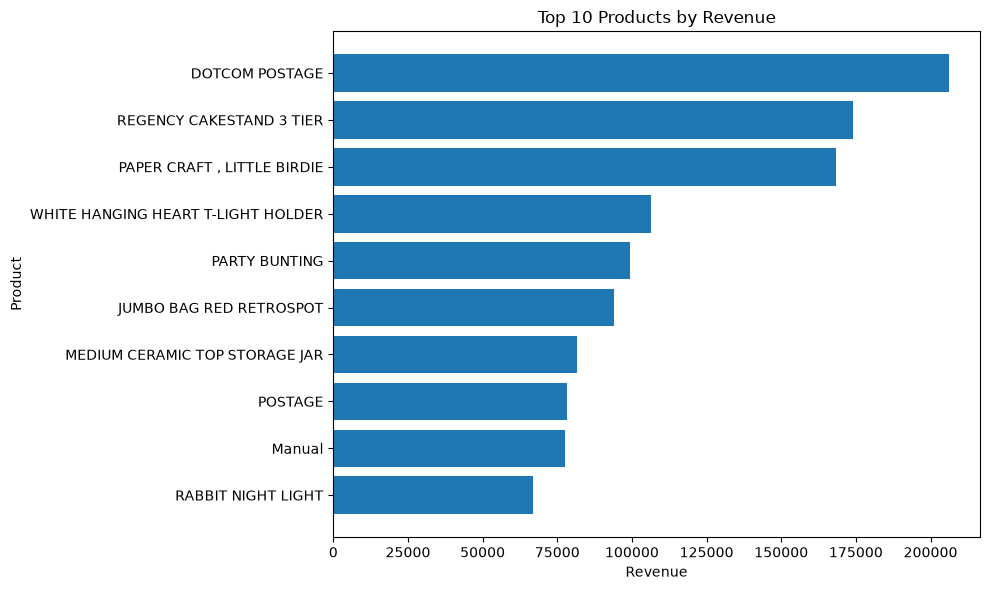

In [101]:
plt.figure(figsize=(10, 6))

top_products = product_sales.head(10)

plt.barh(
    top_products["Description"][::-1],
    top_products["Revenue"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("../visualizations/top_products_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

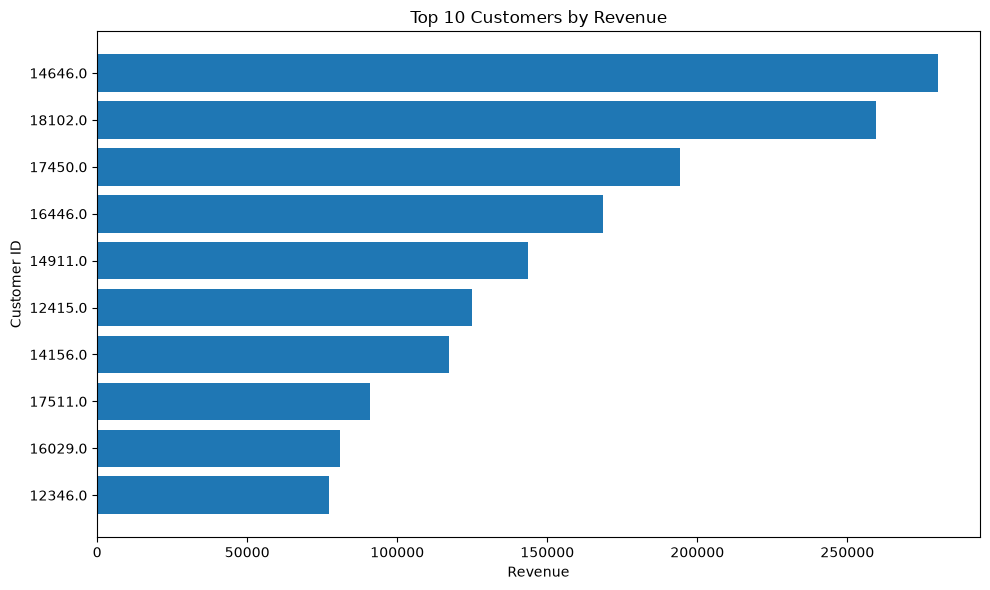

In [102]:
plt.figure(figsize=(10, 6))

top_customers = customer_sales.head(10)

plt.barh(
    top_customers["CustomerID"].astype(str)[::-1],
    top_customers["Revenue"][::-1]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig("../visualizations/top_customers_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

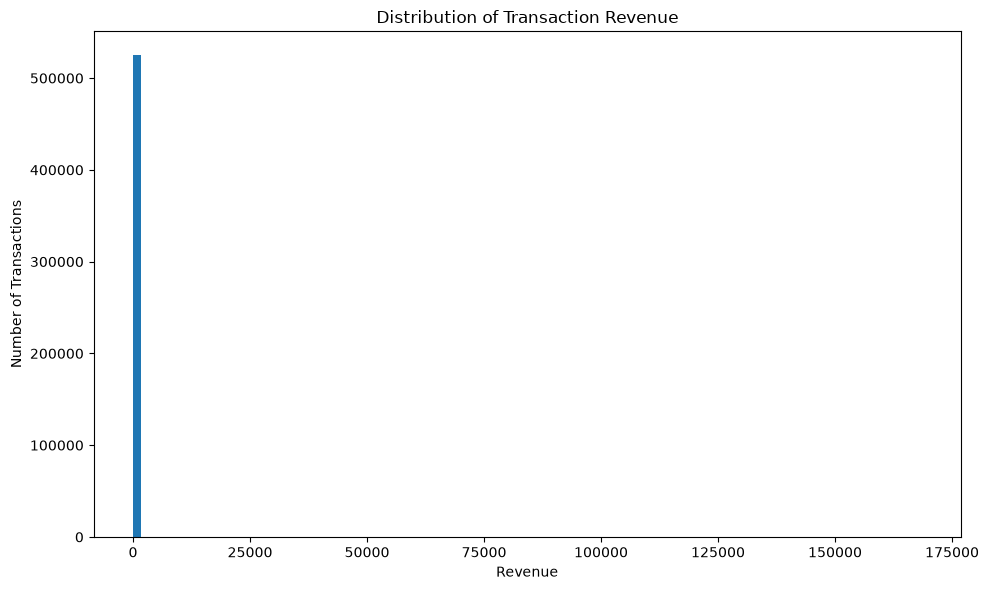

In [103]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["Revenue"],
    bins=100
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../visualizations/revenue_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

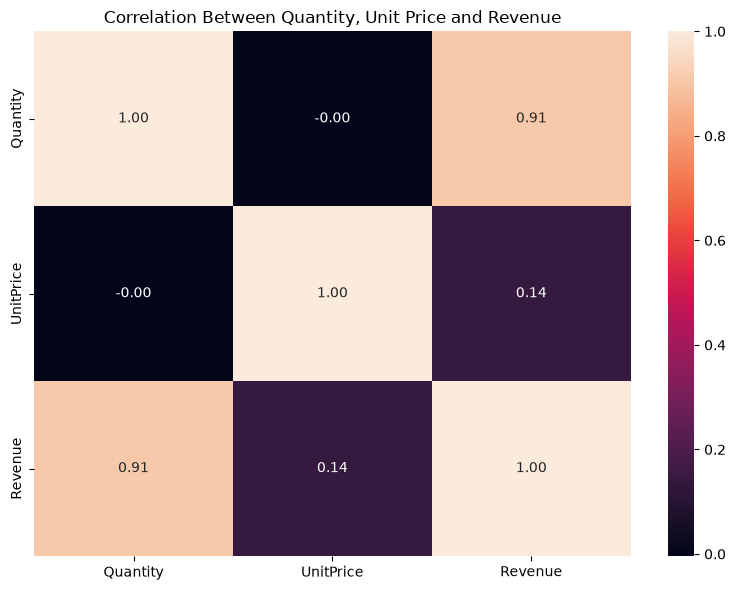

In [104]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Quantity, Unit Price and Revenue")
plt.tight_layout()

plt.savefig("../visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

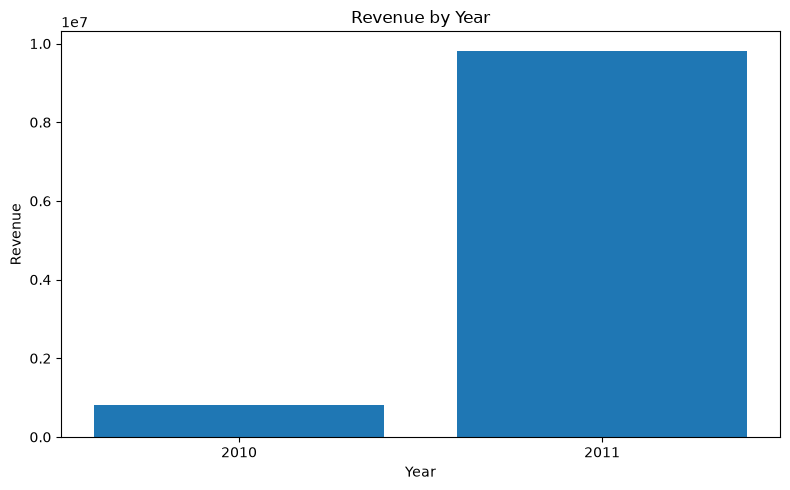

In [105]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Revenue"]
)

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("../visualizations/yearly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

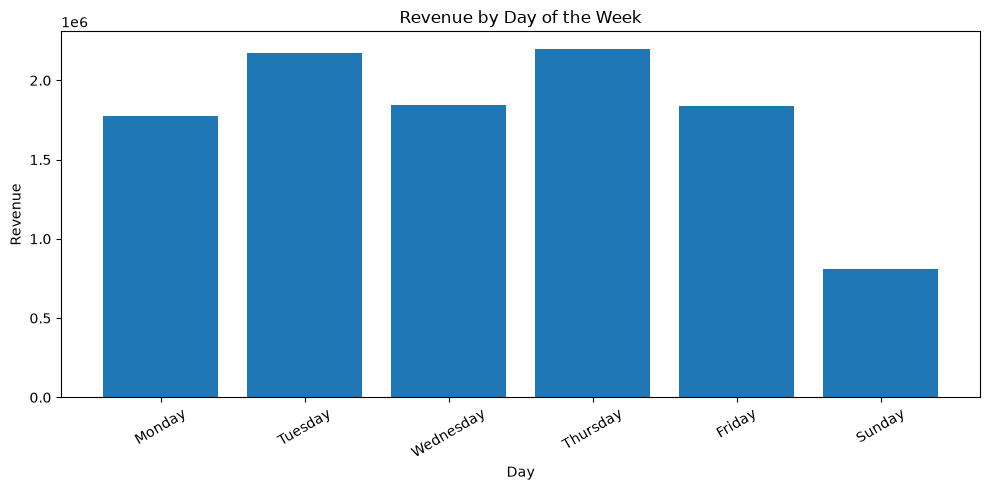

In [106]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_sales["Weekday"],
    weekday_sales["Revenue"]
)

plt.title("Revenue by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("../visualizations/weekday_revenue.png", dpi=300, bbox_inches="tight")
plt.show()